In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [27]:
#Load all files from 1st set

data_path = r"E:\Alok\Job_Prep\Projects_and_Codes\nasa_archive\1st_test\1st_test"
files = sorted(os.listdir(data_path))
print(f"Total snapshots: {len(files)}")

Total snapshots: 2156


In [30]:
df=pd.read_csv(os.path.join(data_path, files[0]))
df.head()

,-0.022\t-0.039\t-0.183\t-0.054\t-0.105\t-0.134\t-0.129\t-0.142
0,-0.105\t-0.017\t-0.164\t-0.183\t-0.049\t0.029\...
1,-0.183\t-0.098\t-0.195\t-0.125\t-0.005\t-0.007...
2,-0.178\t-0.161\t-0.159\t-0.178\t-0.100\t-0.115...
3,-0.208\t-0.129\t-0.261\t-0.098\t-0.151\t-0.205...
4,-0.232\t-0.061\t-0.281\t-0.125\t0.046\t-0.088\...


In [31]:
#add column names to the dataframe
columns = ['b1_ch1', 'b1_ch2', 'b2_ch3', 'b2_ch4', 'b3_ch5', 'b3_ch6', 'b4_ch7', 'b4_ch8']

In [34]:
df_first = pd.read_csv(os.path.join(data_path, files[0]), sep='\t', header=None, names=columns)
df_last = pd.read_csv(os.path.join(data_path, files[-1]), sep='\t', header=None, names=columns)

df_first.head(), df_last.head()

(   b1_ch1  b1_ch2  b2_ch3  b2_ch4  b3_ch5  b3_ch6  b4_ch7  b4_ch8
 0  -0.022  -0.039  -0.183  -0.054  -0.105  -0.134  -0.129  -0.142
 1  -0.105  -0.017  -0.164  -0.183  -0.049   0.029  -0.115  -0.122
 2  -0.183  -0.098  -0.195  -0.125  -0.005  -0.007  -0.171  -0.071
 3  -0.178  -0.161  -0.159  -0.178  -0.100  -0.115  -0.112  -0.078
 4  -0.208  -0.129  -0.261  -0.098  -0.151  -0.205  -0.063  -0.066,
    b1_ch1  b1_ch2  b2_ch3  b2_ch4  b3_ch5  b3_ch6  b4_ch7  b4_ch8
 0  -0.071  -0.117  -0.295  -0.471   0.132  -0.144  -0.173  -0.020
 1  -0.066  -0.068  -0.063  -0.417  -0.271  -0.107  -0.078  -0.081
 2  -0.078  -0.154  -0.193  -0.122  -0.254  -0.154   0.034  -0.107
 3  -0.146  -0.222  -0.320   0.037   0.205  -0.349   0.090  -0.093
 4  -0.083  -0.330  -0.088  -0.176  -0.417   0.103  -0.061  -0.190)

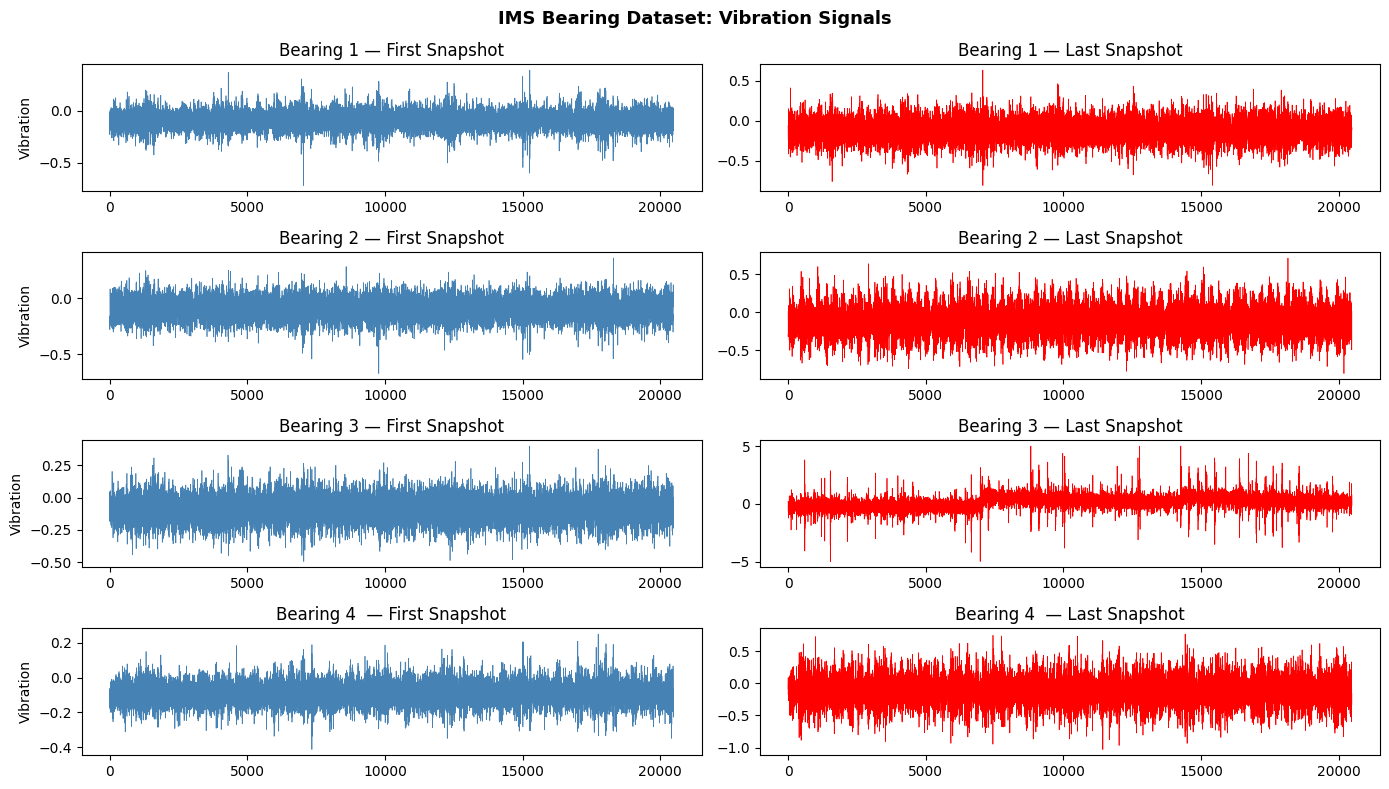

In [42]:
fig, axes = plt.subplots(4, 2, figsize=(14, 8))

bearings = [
    ('b1_ch1', 'Bearing 1'),
    ('b2_ch3', 'Bearing 2'),
    ('b3_ch5', 'Bearing 3'),
    ('b4_ch7', 'Bearing 4 '),]

for i, (col, title) in enumerate(bearings):

    axes[i, 0].plot(df_first[col], color='steelblue', linewidth=0.5)
    axes[i, 0].set_title(f'{title} — First Snapshot')
    axes[i, 0].set_ylabel('Vibration')
    
    axes[i, 1].plot(df_last[col], color='red', linewidth=0.5)
    axes[i, 1].set_title(f'{title} — Last Snapshot')
    
plt.suptitle('IMS Bearing Dataset: Vibration Signals', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/first_vs_last.png', dpi=150, bbox_inches='tight')
plt.show()

Bearing 3 shows dramatic change - 10x amplitude increase  
Bearing 4 shows gradual degradation  
Bearing 1 and 2 shows very minimal change  
ML Goal: detect Bearing 3 and 4 degradation automatically  